In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

In [2]:
from google.colab import files

uploaded = files.upload()

Saving customer_features (1).csv to customer_features (1).csv


In [4]:
import pandas as pd

df = pd.read_csv("customer_features (1).csv")

df.head()

,CustomerID,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded
0,12346.0,326,1,77183.60,NaN,0.000000,20.861862
1,12347.0,2,7,4310.00,60.333333,0.000000,23.681319
2,12348.0,75,4,1797.24,94.000000,0.096774,32.913985
3,12349.0,19,1,1757.55,NaN,0.000000,23.064960
4,12350.0,310,1,334.40,NaN,0.000000,33.767918


In [ ]:
df.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary',
       'AvgDaysBetweenOrders', 'WeekendRatio', 'CountryEncoded'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            4338 non-null   float64
 1   Recency               4338 non-null   int64  
 2   Frequency             4338 non-null   int64  
 3   Monetary              4338 non-null   float64
 4   AvgDaysBetweenOrders  2845 non-null   float64
 5   WeekendRatio          4338 non-null   float64
 6   CountryEncoded        4338 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 237.4 KB


In [ ]:
df["AvgDaysBetweenOrders"] = df["AvgDaysBetweenOrders"].fillna(
    df["AvgDaysBetweenOrders"].median()
)

print(df.isnull().sum())

CustomerID              0
Recency                 0
Frequency               0
Monetary                0
AvgDaysBetweenOrders    0
WeekendRatio            0
CountryEncoded          0
dtype: int64


In [ ]:
X = df[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "AvgDaysBetweenOrders",
        "WeekendRatio",
        "CountryEncoded"
    ]
]

X.head()

,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded
0,326,1,77183.60,53.000000,0.000000,20.861862
1,2,7,4310.00,60.333333,0.000000,23.681319
2,75,4,1797.24,94.000000,0.096774,32.913985
3,19,1,1757.55,53.000000,0.000000,23.064960
4,310,1,334.40,53.000000,0.000000,33.767918


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.28749408 0.18449562]


In [ ]:
wcss = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    wcss.append(model.inertia_)

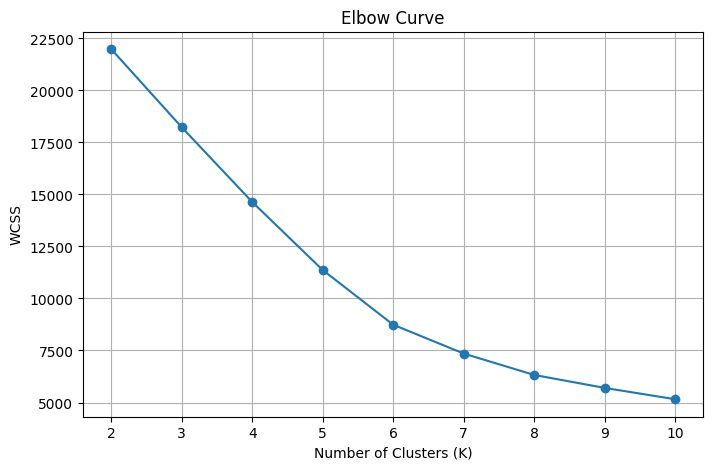

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker='o')

plt.title("Elbow Curve")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded,Cluster
0,12346.0,326,1,77183.60,53.000000,0.000000,20.861862,4
1,12347.0,2,7,4310.00,60.333333,0.000000,23.681319,1
2,12348.0,75,4,1797.24,94.000000,0.096774,32.913985,1
3,12349.0,19,1,1757.55,53.000000,0.000000,23.064960,1
4,12350.0,310,1,334.40,53.000000,0.000000,33.767918,4


In [ ]:
score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.447


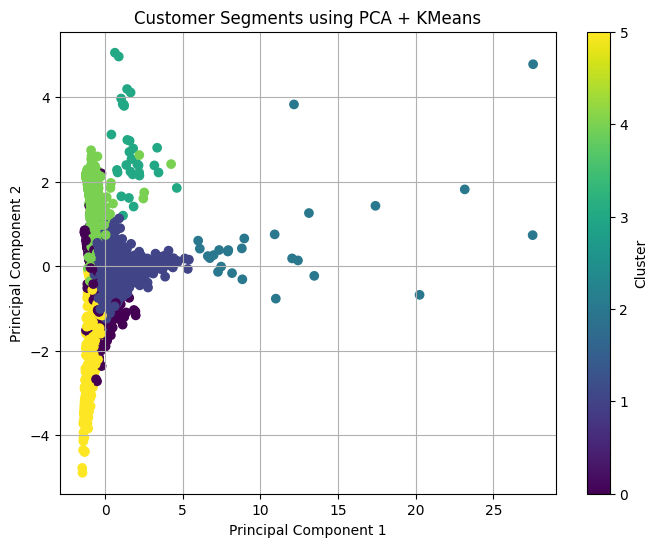

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.title("Customer Segments using PCA + KMeans")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.grid(True)

plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster").mean()

cluster_summary

,CustomerID,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded
Cluster,,,,,,,
0,15380.722101,97.201313,2.888403,886.989389,55.879824,0.853593,21.072227
1,15284.101587,40.168254,5.188492,2072.929636,51.527893,0.051084,21.378829
2,15208.615385,6.038462,66.423077,85826.078077,14.238205,0.052527,29.639129
3,12917.212121,104.424242,3.696970,3552.522121,66.899711,0.100918,109.586139
4,15391.723727,250.826652,1.567714,658.386978,52.146968,0.009747,21.299140
5,15303.406332,54.517150,2.218997,795.962058,206.854881,0.106214,21.257095


In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.01,   # Detect top 1% anomalies
    random_state=42
)

df["Anomaly"] = iso.fit_predict(X_scaled)

print(df["Anomaly"].value_counts())

Anomaly
 1    4294
-1      44
Name: count, dtype: int64


In [ ]:
anomalies = df[df["Anomaly"] == -1]

print("Number of Anomalous Customers:", len(anomalies))

anomalies.head(10)

Number of Anomalous Customers: 44


,CustomerID,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded,Cluster,Anomaly
33,12386.0,338,2,401.90,29.000000,0.000000,117.234386,3,-1
34,12388.0,16,6,2780.66,61.800000,0.220000,117.234386,3,-1
55,12415.0,24,21,124914.53,15.150000,0.000000,117.234386,2,-1
62,12424.0,163,2,1760.96,0.000000,0.000000,117.234386,3,-1
69,12431.0,36,15,6419.95,23.714286,0.128205,117.234386,3,-1
73,12435.0,80,2,7829.89,188.000000,0.000000,49.882474,5,-1
111,12483.0,17,8,2484.98,45.285714,0.213333,85.261844,3,-1
236,12638.0,33,1,671.69,53.000000,1.000000,85.261844,3,-1
324,12744.0,52,7,21279.29,44.000000,0.000000,95.852658,3,-1
326,12748.0,1,209,33053.19,1.432692,0.154352,20.861862,2,-1


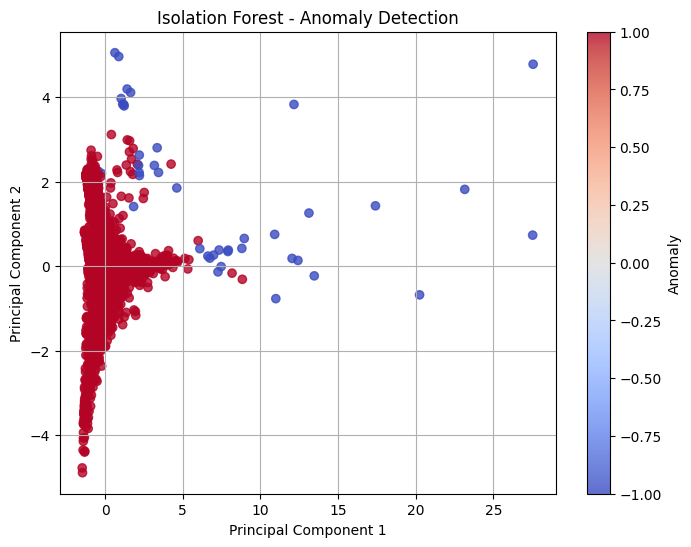

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Anomaly"],
    cmap="coolwarm",
    alpha=0.8
)

plt.title("Isolation Forest - Anomaly Detection")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Anomaly")

plt.grid(True)

plt.show()

In [ ]:
df.to_csv("customer_segmentation_output.csv", index=False)

print("Customer segmentation output saved successfully!")

Customer segmentation output saved successfully!
